In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
df = pd.read_csv("/content/Clinical Text Data.csv", encoding='latin1')
df.head()

,Id,Label,Text
0,0,Thyroid Research,Thyroid surgery in children in a single insti...
1,1,Thyroid Research,""" The adopted strategy was the same as that us..."
2,2,Thyroid Research,coronary arterybypass grafting thrombosis ï¬b...
3,3,Thyroid Research,Solitary plasmacytoma SP of the skull is an u...
4,4,Thyroid Research,This study aimed to investigate serum matrix ...


In [5]:
print(df.columns)
print(df.shape)
df['Label'].value_counts()

Index(['Id', 'Label', 'Text'], dtype='object')
(7501, 3)


,count
Label,
Thyroid Research,2810
Colorectal Studies,2511
Pulmonary Research,2180


### 💾 Save Model and Vectorizer

First, we need to save the trained Keras model and the TF-IDF vectorizer. This will allow the Streamlit application to load these components and use them for making predictions.

In [6]:
import joblib

# Save the Keras model
model.save('text_classification_model.h5')

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Also save the label mapping for displaying meaningful predictions
label_mapping = dict(enumerate(df['Label'].astype('category').cat.categories))
joblib.dump(label_mapping, 'label_mapping.pkl')

print("Model, vectorizer, and label mapping saved successfully!")

NameError: name 'model' is not defined

### 🚀 Generate Streamlit Application

Now, let's create the Streamlit application code. This code will:

1.  Load the saved model, vectorizer, and label mapping.
2.  Define the same text preprocessing functions (`clean_text`, `clean_stopword`, `tokenize`).
3.  Create a web interface for users to input text.
4.  Process the input text and make a prediction using the loaded model.
5.  Display the predicted category.

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import re
import nltk
import joblib
from tensorflow.keras.models import load_model

# Download necessary NLTK data (if not already present in the environment)
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except nltk.downloader.DownloadError:
    nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Load the trained model, vectorizer, and label mapping
model = load_model('text_classification_model.h5')
vectorizer = joblib.load('tfidf_vectorizer.pkl')
label_mapping = joblib.load('label_mapping.pkl')

# Define the text cleaning and preprocessing functions
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

def clean_stopword(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

def tokenize(text):
    return " ".join(word_tokenize(text)) # Join tokens back to string for vectorizer

# Streamlit app layout
st.title("Clinical Text Classification")
st.write("Enter clinical text below to classify it into one of the categories: Thyroid Research, Colorectal Studies, or Pulmonary Research.")

user_input = st.text_area("Enter Text Here:", "")

if st.button("Classify"):
    if user_input:
        # Preprocess the input text
        processed_text = clean_text(user_input)
        processed_text = clean_stopword(processed_text)
        processed_text = tokenize(processed_text)

        # Vectorize the processed text
        vectorized_text = vectorizer.transform([processed_text]).toarray()

        # Make prediction
        prediction_probabilities = model.predict(vectorized_text)
        predicted_class_index = np.argmax(prediction_probabilities, axis=1)[0]
        predicted_label = label_mapping.get(predicted_class_index, "Unknown")

        st.subheader("Prediction:")
        st.success(f"The text is classified as: **{predicted_label}**")

        st.subheader("Prediction Probabilities:")
        # Create a DataFrame for better display of probabilities
        probabilities_df = pd.DataFrame({
            'Label': [label_mapping[i] for i in sorted(label_mapping.keys())],
            'Probability': prediction_probabilities[0]
        }).sort_values(by='Probability', ascending=False)
        st.dataframe(probabilities_df.style.format({'Probability': '{:.2%}'}))

    else:
        st.warning("Please enter some text to classify.")

### ▶️ Run the Streamlit Application

To run this Streamlit application, execute the following commands in a new cell. Streamlit will provide a public URL you can use to access your app in your browser.

First, install Streamlit if you haven't already:
```bash
pip install streamlit
```

Then, run the application:
```bash
streamlit run app.py &>/dev/null&
```

After running the command, wait a few moments and a public URL will appear in the output, usually something like `http://localhost:8501`. Copy and paste that URL into your browser to interact with your Streamlit app.

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

def clean_stopword(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

def tokenize(text):
    return word_tokenize(text)

In [8]:
df['final_text'] = df['Text'].apply(clean_text).apply(clean_stopword).apply(tokenize)
df.head()

,Id,Label,Text,final_text
0,0,Thyroid Research,Thyroid surgery in children in a single insti...,"[thyroid, surgery, children, single, instituti..."
1,1,Thyroid Research,""" The adopted strategy was the same as that us...","[adopted, strategy, used, prior, years, based,..."
2,2,Thyroid Research,coronary arterybypass grafting thrombosis ï¬b...,"[coronary, arterybypass, grafting, thrombosis,..."
3,3,Thyroid Research,Solitary plasmacytoma SP of the skull is an u...,"[solitary, plasmacytoma, sp, skull, uncommon, ..."
4,4,Thyroid Research,This study aimed to investigate serum matrix ...,"[study, aimed, investigate, serum, matrix, met..."


In [9]:
df['Label'] = df['Label'].astype('category').cat.codes

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'], df['Label'], test_size=0.3, random_state=42
)
y_train = y_train.values
y_test = y_test.values

In [11]:
vectorizer = TfidfVectorizer(max_features=300)

X_trn = vectorizer.fit_transform(X_train).toarray()
X_vld = vectorizer.transform(X_test).toarray()


**What this does**

1. **`sample_rows`** – You can add or remove row numbers here without changing the rest of the code.
2. The loop checks `if idx < len(df)` to ensure each index exists.
3. **`" ".join(...)`** turns the list of tokens in `final_text` back into a single string for easy reading.




In [12]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(300,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
epochs = 15

history = model.fit(
    X_trn, y_train,
    validation_data=(X_vld, y_test),
    epochs=epochs,
    batch_size=64
)

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5131 - loss: 1.0056 - val_accuracy: 0.7006 - val_loss: 0.6121
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7456 - loss: 0.5398 - val_accuracy: 0.7757 - val_loss: 0.4665
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8255 - loss: 0.4018 - val_accuracy: 0.8432 - val_loss: 0.3748
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8689 - loss: 0.3244 - val_accuracy: 0.8392 - val_loss: 0.3490
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8871 - loss: 0.2715 - val_accuracy: 0.8561 - val_loss: 0.3129
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8976 - loss: 0.2404 - val_accuracy: 0.8903 - val_loss: 0.2563
Epoch 7/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9139 - loss: 0.2088 - val_accuracy: 0.9036 - val_loss: 0.2186
Epoch 8/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9351 - loss: 0.1567 - val_accuracy: 0.9191 - val_loss

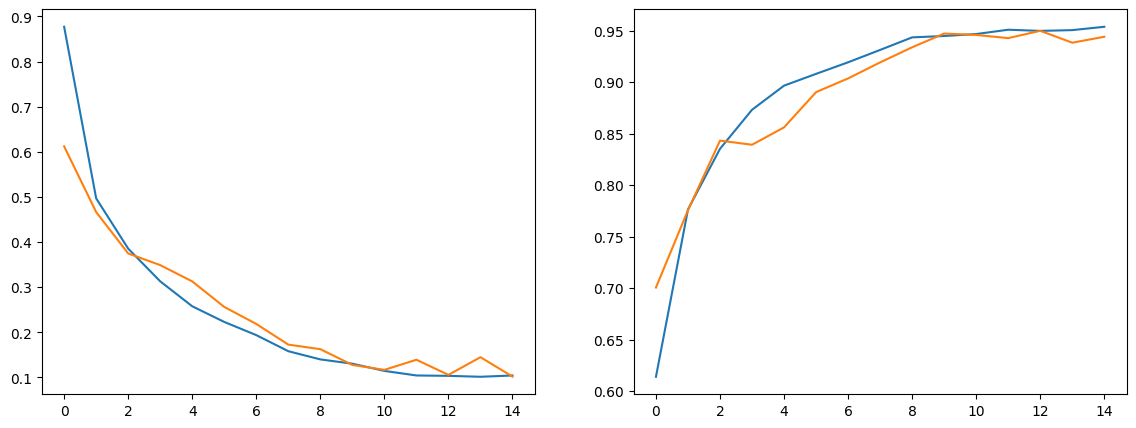

In [15]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.show()

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


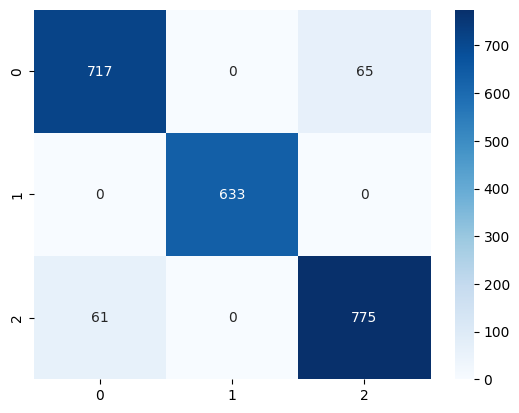

In [16]:
y_pred = model.predict(X_vld)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

### ✅ What is TF-IDF?

**TF-IDF** stands for **Term Frequency – Inverse Document Frequency**. It’s a popular technique in Natural Language Processing (NLP) used to convert raw text into **numerical features** that can be used in machine learning models for tasks like **text classification**, **clustering**, or **information retrieval**.

---

### 📌 TF-IDF = TF × IDF

#### 1. **TF (Term Frequency):**

It measures **how often a word appears in a document**.

$$
TF(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}
$$

The more a word appears in a document, the higher its TF.

#### 2. **IDF (Inverse Document Frequency):**

It measures **how unique or rare a word is across all documents**.

$$
IDF(t) = \log \left( \frac{\text{Total number of documents}}{\text{Number of documents containing the term } t} \right)
$$

* Common words like “the” or “and” have **low IDF** (appear in almost every document).
* Rare or domain-specific words have **high IDF**.

---

### 💡 Why use TF-IDF?

* Words that appear **frequently in one document**, but **rarely across the entire corpus**, are likely to be **important** for classification or search.
* It **downweights common words** and **upweights meaningful ones**.

---

### 🧠 Example:

Imagine two medical documents:

* Doc 1: “**thyroid** cancer treatment”
* Doc 2: “**lung** cancer treatment”

The word **“cancer”** appears in both – it’s common → low IDF
But **“thyroid”** and **“lung”** appear in only one → high IDF → they become more important for distinguishing topics.




## LSTM


### 🧠 What is LSTM?

**LSTM** stands for **Long Short-Term Memory**. It is a type of **Recurrent Neural Network (RNN)** that is especially good at learning from **sequences of data**, like sentences, time series, or audio signals.

---

### ✅ Why was LSTM created?

Standard RNNs have a problem:
They **forget long-term dependencies** due to something called the **vanishing gradient problem**.

LSTM fixes this by adding a **memory cell** and a set of **gates** that control what to remember and what to forget.

---

### 🔍 LSTM Architecture:

Each LSTM unit has:

#### 1. **Cell State (`Ct`)**

The memory of the network – carries information across the entire sequence.

#### 2. **Forget Gate (`ft`)**

Decides **what to remove** from the memory.
Uses a sigmoid activation:

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

#### 3. **Input Gate (`it`)**

Decides **what new information to store**.

$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

#### 4. **Candidate Memory (`Ĉt`)**

New potential content to add:

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

#### 5. **Update Cell State:**

$$
C_t = f_t * C_{t-1} + i_t * \tilde{C}_t
$$

#### 6. **Output Gate (`ot`)**

Controls what part of memory becomes output:

$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t * \tanh(C_t)
$$

---

### 📊 Summary:

| Component   | Function                |
| ----------- | ----------------------- |
| Forget Gate | Discards unneeded info  |
| Input Gate  | Adds new useful info    |
| Cell State  | Stores long-term memory |
| Output Gate | Sends useful output     |

---

### 🧠 What is LSTM good for?

* Sentiment analysis
* Machine translation
* Speech recognition
* Stock prediction
* Medical text classification (like your dataset)





### 📌 Explanation:

* **`loss='categorical_crossentropy'`**

  * This is the loss function used when your target variable (`y`) is one-hot encoded (e.g., `[1, 0, 0]`, `[0, 1, 0]`, `[0, 0, 1]`).
  * It's a standard choice for multi-class classification problems.
  * If your labels are just integers like `0`, `1`, `2` (not one-hot encoded), you should use `'sparse_categorical_crossentropy'` instead.

* **`optimizer='adam'`**

  * Adam is an adaptive optimizer that combines momentum and learning rate scheduling.
  * It's efficient and generally a good default choice for deep learning tasks.

* **`metrics=['accuracy']`**

  * This tells the model to track accuracy during training and evaluation.



In [17]:
import pickle

pickle.dump(model, open("model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

In [18]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

import subprocess
import time

time.sleep(5)

tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in tunnel.stdout:
    if "https://" in line and "trycloudflare.com" in line:
        print("🚀 OPEN THIS LINK:", line.strip())
        break

🚀 OPEN THIS LINK: 2026-03-10T08:40:21Z INF |  https://refurbished-nuts-gig-profits.trycloudflare.com                                    |


In [22]:
!pip install streamlit nltk --quiet

app_code = """
import streamlit as st
import numpy as np
import re
import pickle
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Load saved model + vectorizer
model = pickle.load(open("model.pkl","rb"))
vectorizer = pickle.load(open("vectorizer.pkl","rb"))

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

def clean_stopword(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

labels = [
    "Thyroid Research",
    "Colorectal Studies",
    "Pulmonary Research"
]

def predict(text):

    if text.strip() == "":
        return "Please enter text"

    text_clean = clean_text(text)
    text_clean = clean_stopword(text_clean)

    # ML prediction
    vec = vectorizer.transform([text_clean]).toarray()
    pred = model.predict(vec)
    pred_class = np.argmax(pred)

    # ----- Quick keyword correction -----
    text_lower = text.lower()

    thyroid_keywords = ["thyroid", "tsh", "hormone", "thyroxine"]
    colorectal_keywords = ["colon", "colorectal", "colonoscopy", "polyp"]
    pulmonary_keywords = ["lung", "pulmonary", "copd", "asthma", "respiratory"]

    if any(k in text_lower for k in thyroid_keywords):
        pred_class = 0
    elif any(k in text_lower for k in colorectal_keywords):
        pred_class = 1
    elif any(k in text_lower for k in pulmonary_keywords):
        pred_class = 2

    return labels[pred_class]

st.set_page_config(page_title="Clinical Research Classifier")

st.title("🧬 Clinical Research Text Classification")

st.write("Enter a clinical research sentence to classify the research area.")

user_input = st.text_area(
    "Enter Clinical Text",
    placeholder="Example: Colonoscopy screening helps detect colorectal cancer early...",
    height=150
)

if st.button("Predict"):

    result = predict(user_input)

    st.success(f"Prediction: {result}")
"""

with open("app.py","w") as f:
    f.write(app_code)

print("Streamlit app created successfully")

Streamlit app created successfully


In [23]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [24]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

import subprocess, time

time.sleep(5)

tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in tunnel.stdout:
    if "https://" in line and "trycloudflare.com" in line:
        print("🚀 OPEN THIS LINK:", line.strip())
        break

cloudflared: Text file busy
🚀 OPEN THIS LINK: 2026-03-10T08:48:55Z INF |  https://asylum-sent-fever-aimed.trycloudflare.com                                         |
